In [3]:
!pip3 install torch
!pip3 install torchvision

# 주석을 달거나 설명을 달 수 있는 기능
# 새 머신러닝 개념 파악용 샘플 코드

In [4]:
from google.colab import drive
# drive.mount('/content/gdrive')

MessageError: Error: credential propagation was unsuccessful

머신러닝 코드 흐름
데이터 준비 -> 데이터 탐색 -> 데이터 전처리 -> 학습(훈련) -> 평가 -> 예측 -> 모델 저장

1. 라이브러리 불러오기

In [2]:
# 표 형태로 데이터를 다루기 위함
import pandas as pd
# 숫자 계산을 빠르게 하기 위한 라이브러리 (배열)
import numpy as np
# 그래프 그리기위한 라이브러리
import matplotlib.pyplot as plt
# 보기 좋은 통계 그래프
import seaborn as sns

# 머신러닝 모델, 데이터셋, 평가 도구를 제공
from sklearn.datasets import load_iris                # 데이터셋
# 데이터셋 분리 (데이터를 훈련 | 평가(테스트) 용으로 나눔)
from sklearn.model_selection import train_test_split
# 데이터 값을 표준화 하는 전처리 도구 (스케일링)
from sklearn.preprocessing import StandardScaler
# 분류 문제에 많이 쓰이는 머신러닝 모델
from sklearn.ensemble import RandomForestClassifier
# 정확도 계산
from sklearn.metrics import accuracy_score
# 정밀도, 재현율, F1-score 출력 (보고서용)
from sklearn.metrics import classification_report
# 실제값과 예측값의 차이를 표로 확인
from sklearn.metrics import confusion_matrix

# 학습된 모델을 파일로 저장하고 불러오기 위한 라이브러리
import joblib

from sklearn.model_selection import train_test_split


2. 데이터 불러오기


In [4]:
# iris 데이터셋 불러오기
# iris 데이터는 붓꽃의 꽃받침, 꽃잎 길이 / 너비를 이용해서 품종을 분류하는 예제 데이터
iris = load_iris()

# 입력 데이터 X (머신러닝 모델이 훈련에 사용할 데이터)
X = iris.data

# 정답 데이터 y (각 붓꽃의 실제 품종 번호)
y = iris.target

# 컬럼 이름
feature_names = iris.feature_names

# 품종 이름
target_names = iris.target_names

# 데이터프레임으로 변환
df = pd.DataFrame(X, columns=feature_names)

# 정답을 컬럼으로 추가
df['target'] = y

# 숫자로 된 target 을 실제 품종이름으로 변환한 컬럼도 추가
df['target_name'] = df['target'].apply(lambda x: target_names[x])

# 데이터 위 5개만 출력 확인
df.head()
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


3. 데이터 기본 정보 확인

In [5]:
# 데이터 행과 열 개수 확인
print('데이터 크기 : ', df.shape)

# 데이터 컬럼 정보 확인
print('\n컬럼 정보 : ')
print(df.info())

# 숫자 데이터의 평균, 표준편차, 최소값, 최대값 확인
print('\n기초 통계량 : ')
print(df.describe())

# 품종별 데이터 개수 확인
print('\n품종별 개수 : ')
print(df['target_name'].value_counts())



데이터 크기 :  (150, 6)

컬럼 정보 : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

기초 통계량 : 
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%            

4. 데이터 시각화


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

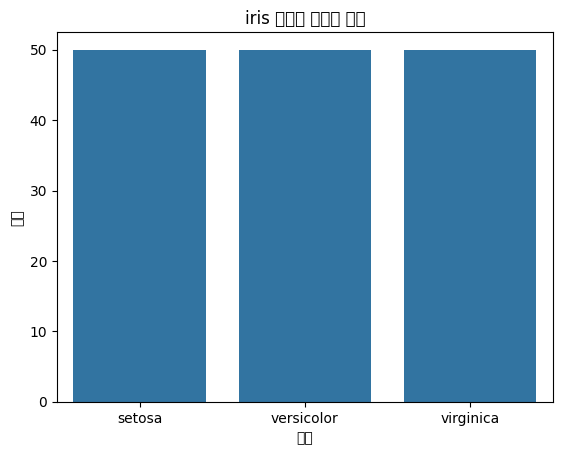

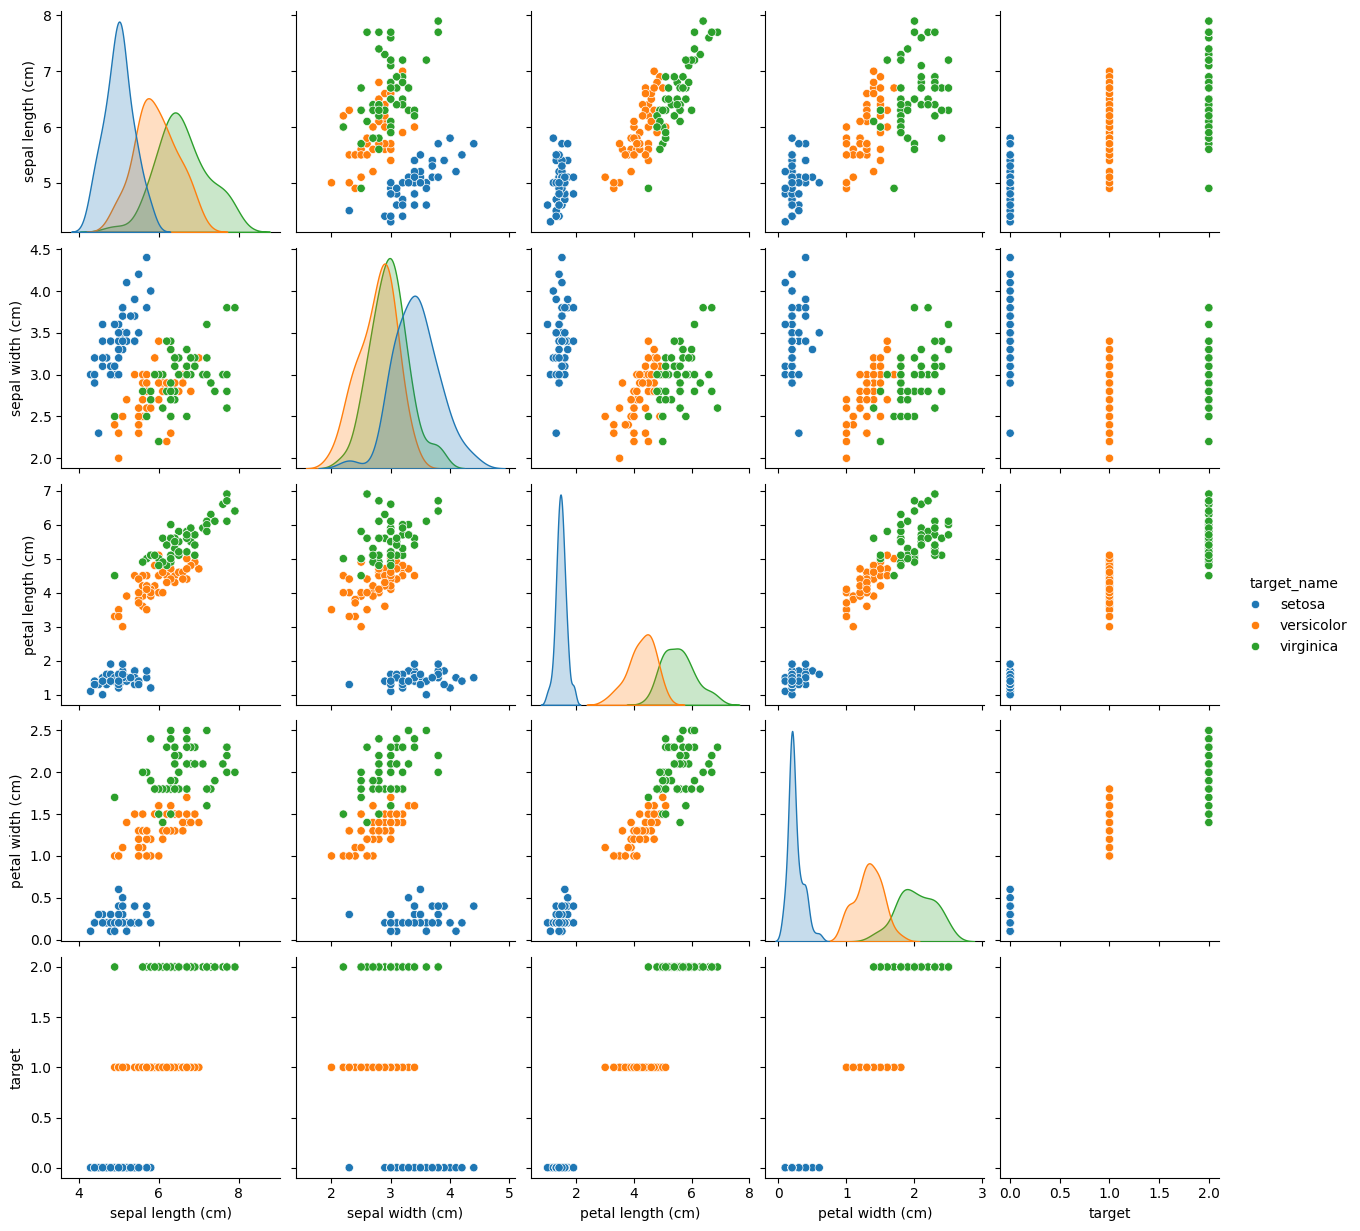

In [6]:
# 품종별 데이터 개수를 막대 그래프로 확인
sns.countplot(data=df, x='target_name')
plt.title('iris 품종별 데이터 개수')
plt.xlabel('품종')
plt.ylabel('개수')
plt.show()

# 변수 간 관계를 산점도 행렬로 확인 : hue 는 품종별로
sns.pairplot(df, hue='target_name')
plt.show()

5. 입력 데이터와 정답 데이터 분리

In [7]:
# 머신러닝 모델에 넣을(읽게 할 훈련시킬) 값 (입력값) : target, target_name 은 정답이기 때문에 제외
X = df[feature_names]

# 머신러닝 모델이 맞춰야 하는 정답
y = df['target']

print('입력 데이터 X 크기 : ', X.shape)
print('정답 데이터 y 크기 : ', y.shape)
#

입력 데이터 X 크기 :  (150, 4)
정답 데이터 y 크기 :  (150,)


6. 학습용(훈련용) 데이터와 테스트용(평가용) 데이터 분리

In [10]:
# 학습용 데이터 : 모델이 공부하는 데이터
# 테스트용 데이터 : 모델이 처음보는 문제를 잘 맞추는지 확인하는 데이터
X_train, X_test, y_train, y_test = train_test_split(
    X,                # 입력 데이터
    y,                # 정답 데이터
    test_size=0.2,    # 전체 데이터 총 20% 를 테스트용으로 사용
    random_state=42,  # 실행할 때 마다 같은 결과가 나오도록 고정
    stratify=y)       # 품종비율이 학습/ 테스트 데이터에 비슷하게 나눠주도록 설정

print('학습용 입력 데이터 : ', X_train.shape)
print('테스트용 입력 데이터 : ', X_test.shape)
print('학습용 정답 데이터 : ', y_train)
print('테스트용 정답 데이터 : ', y_test)

학습용 입력 데이터 :  (120, 4)
테스트용 입력 데이터 :  (30, 4)
학습용 정답 데이터 :  8      0
106    2
76     1
9      0
89     1
      ..
37     0
2      0
33     0
52     1
3      0
Name: target, Length: 120, dtype: int64
테스트용 정답 데이터 :  38     0
127    2
57     1
93     1
42     0
56     1
22     0
20     0
147    2
84     1
107    2
141    2
104    2
51     1
7      0
49     0
14     0
69     1
63     1
138    2
10     0
140    2
58     1
134    2
132    2
77     1
75     1
18     0
116    2
28     0
Name: target, dtype: int64


7. 데이터 전처리 - 표준화


In [11]:
# StandardScale 는 평균을 0, 표준편차를 1에 가깝게 변환함
# 변수마다 단위나 크기가 다를 때, 모델 학습을 안정적으로 도와줌
scaler = StandardScaler()

# fit_transform : 학습용 데이터의 평균과 표준편차를 계싼한 뒤 변환까지 수행
X_train_scaled = scaler.fit_transform(X_train)

# transform : 테스트 데이터는 학습 데이터 기준으로만 변환해야 함
# 테스트 데이터 기준으로 새로 fit 하면 데이터 누수가 발생할 수 있음
X_test_scaled = scaler.transform(X_test)

print('표준화 전 학습 데이터 : ')
print(X_train.head())

print('\n표준화 후 학습 데이터 : ')
print(X_test_scaled[:5])



표준화 전 학습 데이터 : 
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
8                  4.4               2.9                1.4               0.2
106                4.9               2.5                4.5               1.7
76                 6.8               2.8                4.8               1.4
9                  4.9               3.1                1.5               0.1
89                 5.5               2.5                4.0               1.3

표준화 후 학습 데이터 : 
[[-1.72156775 -0.10821272 -1.40250384 -1.32327558]
 [ 0.30848902 -0.10821272  0.64163131  0.78343181]
 [-1.12449223 -1.45154306 -0.2668732  -0.26992188]
 [-1.00507713 -1.67543145 -0.2668732  -0.26992188]
 [-1.72156775  0.33956406 -1.40250384 -1.32327558]]


8. 머신러닝 모델 생성


In [12]:
# RandomForestClassifier
# 여러 개의 결정 트리를 만들어 다수결 방식으로 예측하는 분류 모델

model = RandomForestClassifier(
    n_estimators=100,   # 결정 트리 100 개 사용
    random_state=42,    # 결과 재현을 위한 고정값
)

9. 모델 학습 (훈련)

In [14]:
# fit() 함수 : 모델 학습 시키는 함수
model.fit(X_train_scaled, y_train)

print('모델 학습 완료')

모델 학습 완료


10. 테스트(평가) 데이터로 결과 예측 확인

In [15]:
# predict() 함수 : 새로운 데이터에 대한 정답을 예측함

y_pred = model.predict(X_test_scaled)

print('예측 결과 : ', y_pred)
print('\n실제 정답 : ', y_test.values)

예측 결과 :  [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]

실제 정답 :  [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


11. 모델 평가 - 정확도

In [16]:
# accuracy_score :
# 전체 테스트 데이터 중 몇 개를 맞혔는지 비율로 계산

accuracy = accuracy_score(y_test, y_pred)

print('모델 정확도 : ', accuracy)
print('모델 정확도 (%) : ', accuracy * 100)

모델 정확도 :  0.9
모델 정확도 (%) :  90.0


12. 모델 평가 - 상세 평가 지표

In [17]:
# classification_report :
# precision : 예측한 것 중 실제로 맞은 비율
# recall : 실제 정답 중 모델이 맞힌 비율
# f1-score : precision 과 recoil 을 종합한 점수

print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



13. 혼돈 행렬 확인

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


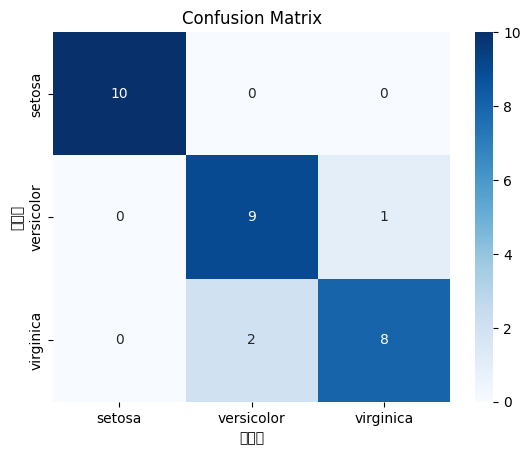

혼동 행렬 : 
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [19]:
# confusion_matrix :
# 실제 정답과 모델이 예측한 결과가 어떻게 다른지 표로 확인함

cm = confusion_matrix(y_test, y_pred)

# 혼동 행렬을 그래프로 표현
sns.heatmap(
    cm,                         # 행렬
    annot=True,                 # 숫자 표시
    fmt='d',                    # 정수 형태로 표시
    cmap='Blues',               # 색상 테마
    xticklabels=target_names,   # 좌표축 이
    yticklabels=target_names
)
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title('Confusion Matrix')
plt.show()

print('혼동 행렬 : ')
print(cm)

14. 새로운 데이터로 예측 결과 확인

In [20]:
# 새로운 봇꽃 데이터 준비
# 순서 : sepal length, sepal width, petal length, petal width

new_data = [[5.1, 3.5, 1.4, 0.2]]

# 새 데이터도 학습 데이터와 같은 기준으로 표준화해야 함
new_data_scaled = scaler.transform(new_data)

# 모델로 품종 예측
new_pred = model.predict(new_data_scaled)

# 예측한 품종 번호를 품종이름으로 변환
pred_name = target_names[new_pred[0]]

print('새 데이터 예측한 번호 : ', new_pred[0])
print('새 데이터 예측한 품종 : ', pred_name)

새 데이터 예측한 번호 :  0
새 데이터 예측한 품종 :  setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


15. 모델 저장<br>
구글 코랩에서 파일 저장하면, 코랩의 가상 Linux 환경 ( 임시 서버) 안에 저장됨<br>
코랩 왼쪽의 파일 탐색기에서 확인 가능

In [21]:
# 학습(훈련)된 모델 저장
joblib.dump(model, 'iris_random_forest_model.pkl')
# 모델 파일의 확장자는 임의대로 지정
# pkl == python 객체를 저장한 pickle 파일을 의미함
# 주로 머신러닝 모델 파일에 많이 사용됨
# joblib 와 pickle 라이브러리는 pkl 파일 입출력함

# 표준화 도구도 함께 저장 :
# 나중에 새 데이터를 예측할 때 같은 전처리를 해야 하기 떄문임
joblib.dump(scaler, 'iris_scaler.pkl')

print('모델과 전처리 도구 저장 완료')


모델과 전처리 도구 저장 완료


16. 저장된 모델 불러오기 (또는 외부에서 다운받은 모델 파일 불러오기)

In [22]:
# 저장된 모델 파일 불러오기
loaded_model = joblib.load('iris_random_forest_model.pkl')

# 저장된 scaler 파일 불러오기
loaded_scaler = joblib.load('iris_scaler.pkl')

print('불러오기 완료')

불러오기 완료


17. 불러온 모델로 다시 예측

In [23]:
# 예측할 새 데이터 준비
sample = [[6.2, 3.4, 5.4, 2.3]]

# 저장된 scaler 로 표준화
sample_scaled = loaded_scaler.transform(sample)

# 저장된 모델로 예측
sample_pred = loaded_model.predict(sample)

# 예측 결과 출력
print('예측된 품종 번호 : ', sample_pred[0])
print('예측된 품종 이름 : ', target_names[sample_pred[0]])

예측된 품종 번호 :  2
예측된 품종 이름 :  virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
